# Ноутбук 2: Маржинальный анализ (Unit-экономика)

## 1. Что я делаю

В предыдущем ноутбуке я провёл аудит данных и обнаружил, что логистические затраты составляют 78.7% от выручки, а возвраты — ещё 6.1%. Это означает, что **выручка может не приносить прибыль**, и часть товаров может работать в минус.

В этом ноутбуке я считаю **реальную маржинальность** каждого товара, категории и канала продаж с учётом **всех затрат**:

- **Себестоимость товара** (цена закупки у поставщика)
- **Логистика:**
  - Доставка до пункта выдачи (delivery_to_pvz)
  - Хранение на складе маркетплейса (storage_fbo)
  - Хранение в пункте выдачи (storage_pvz)
  - Возвратная логистика (return_delivery)
- **Возвраты:** потери от возврата денег клиенту + утилизация испорченных товаров
- **Скидки:** влияние ручных и системных скидок на маржу

### Результат
Я выявлю убыточные товары и категории, покажу, где бизнес теряет деньги, и дам рекомендации по ценообразованию, ассортименту и логистике с оценкой финансового эффекта.

## 2: Загрузка и подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.0f}'.format)

In [2]:
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'warning': '#C73E1D',
    'success': '#3B1F2B',
    'profit': '#2E86AB',
    'loss': '#C73E1D',
}

In [3]:
DATA_PATH = "data/"

print("Загрузка данных...")

# Загружаю все необходимые таблицы
products = pd.read_csv(os.path.join(DATA_PATH, "products.csv"))
sales = pd.read_csv(os.path.join(DATA_PATH, "sales.csv"))
purchases = pd.read_csv(os.path.join(DATA_PATH, "purchases.csv"))
returns = pd.read_csv(os.path.join(DATA_PATH, "returns.csv"))
logistics = pd.read_csv(os.path.join(DATA_PATH, "logistics_costs.csv"))
customers = pd.read_csv(os.path.join(DATA_PATH, "customers_clean.csv"))

# Приведение дат
sales["order_date"] = pd.to_datetime(sales["order_date"])
sales["delivery_date"] = pd.to_datetime(sales["delivery_date"])
purchases["purchase_date"] = pd.to_datetime(purchases["purchase_date"])
purchases["delivery_date"] = pd.to_datetime(purchases["delivery_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])
logistics["cost_date"] = pd.to_datetime(logistics["cost_date"])

print(f"Загружено:")
print(f"  products: {len(products):,} товаров")
print(f"  sales: {len(sales):,} строк продаж")
print(f"  purchases: {len(purchases):,} закупок")
print(f"  returns: {len(returns):,} возвратов")
print(f"  logistics: {len(logistics):,} записей о затратах")
print(f"  customers_clean: {len(customers):,} клиентов")

# Применяю очистку customer_id из ноутбука 01
# (если ноутбук запущен отдельно — повторяю логику склейки дубликатов)

# Обновляю customer_id в sales и returns на канонические
# Для этого нахожу дубликаты в customers_clean (если есть поле original_customer_id)
if "original_customer_id" in customers.columns:
    canonical_map = dict(zip(customers["original_customer_id"], customers["customer_id"]))
    # Добавляю маппинг для тех, кто не дубликат
    for cid in customers["customer_id"]:
        if cid not in canonical_map:
            canonical_map[cid] = cid
    sales["customer_id"] = sales["customer_id"].map(lambda x: canonical_map.get(x, x))
    returns["customer_id"] = returns["customer_id"].map(lambda x: canonical_map.get(x, x))
    print("  ✓ customer_id в sales и returns обновлены на канонические")

Загрузка данных...
Загружено:
  products: 3,000 товаров
  sales: 58,664 строк продаж
  purchases: 3,717 закупок
  returns: 3,519 возвратов
  logistics: 115,880 записей о затратах
  customers_clean: 4,500 клиентов
  ✓ customer_id в sales и returns обновлены на канонические


### 2.1. Присоединение себестоимости к продажам

In [4]:
# Средняя цена закупки по каждому товару
avg_purchase_price = purchases.groupby("product_id")["purchase_price"].mean().reset_index()
avg_purchase_price.columns = ["product_id", "avg_purchase_price"]

# Присоединяю к продажам (исключаю warehouse_type из products, чтобы не было дубликата)
sales = sales.merge(
    products[["product_id", "category", "base_cost", "base_price", "abc_class"]], 
    on="product_id", how="left"
)
sales = sales.merge(avg_purchase_price, on="product_id", how="left")

# Если по какой-то причине avg_purchase_price пуст — использую base_cost
sales["avg_purchase_price"].fillna(sales["base_cost"], inplace=True)

print(f"  Средняя себестоимость товара: {sales['avg_purchase_price'].mean():.0f} ₽")
print(f"  Средняя цена продажи: {sales['unit_price'].mean():.0f} ₽")

  Средняя себестоимость товара: 166 ₽
  Средняя цена продажи: 248 ₽


### 2.2. Присоединение логистических затрат

In [5]:
print("\nПрисоединение логистических затрат...")

# Доставка до ПВЗ — на уровне товара в заказе
delivery_costs = logistics[logistics["cost_type"] == "delivery_to_pvz"][
    ["order_id", "product_id", "cost_amount"]
].copy()
delivery_costs.columns = ["order_id", "product_id", "delivery_cost"]

# Хранение FBO — на уровне товара помесячно.
# Распределяю на sales пропорционально количеству продаж товара в этом месяце.
# Упрощённый подход: среднее хранение на единицу товара за весь период
fbo_storage = logistics[logistics["cost_type"] == "storage_fbo"].copy()
fbo_storage["cost_month"] = fbo_storage["cost_date"].dt.to_period("M")

# Суммарное хранение по каждому товару
fbo_by_product = fbo_storage.groupby("product_id")["cost_amount"].sum().reset_index()
fbo_by_product.columns = ["product_id", "total_storage_fbo_cost"]

# Количество продаж каждого товара
product_sales_count = sales.groupby("product_id").size().reset_index()
product_sales_count.columns = ["product_id", "total_sales_count"]

# Средняя стоимость хранения на единицу товара
fbo_unit_cost = fbo_by_product.merge(product_sales_count, on="product_id", how="left")
fbo_unit_cost["storage_fbo_per_unit"] = fbo_unit_cost["total_storage_fbo_cost"] / fbo_unit_cost["total_sales_count"]
fbo_unit_cost["storage_fbo_per_unit"].fillna(0, inplace=True)

# Присоединяю к sales
sales = sales.merge(delivery_costs, on=["order_id", "product_id"], how="left")
sales = sales.merge(fbo_unit_cost[["product_id", "storage_fbo_per_unit"]], on="product_id", how="left")
sales["storage_fbo_per_unit"].fillna(0, inplace=True)

# Хранение в ПВЗ — на уровне заказа. Распределяю на товары внутри заказа
pvz_storage = logistics[logistics["cost_type"] == "storage_pvz"][
    ["order_id", "cost_amount"]
].copy()
pvz_storage.columns = ["order_id", "storage_pvz_total"]

# Количество товаров в заказе
order_items_count = sales.groupby("order_id").size().reset_index()
order_items_count.columns = ["order_id", "items_in_order"]

# Распределяю хранение ПВЗ поровну на все товары заказа
pvz_per_item = pvz_storage.merge(order_items_count, on="order_id", how="left")
pvz_per_item["storage_pvz_per_unit"] = pvz_per_item["storage_pvz_total"] / pvz_per_item["items_in_order"]

sales = sales.merge(pvz_per_item[["order_id", "storage_pvz_per_unit"]], on="order_id", how="left")
sales["storage_pvz_per_unit"].fillna(0, inplace=True)

# Итоговая логистика на единицу товара
sales["logistics_total"] = (
    sales["delivery_cost"].fillna(0) + 
    sales["storage_fbo_per_unit"] + 
    sales["storage_pvz_per_unit"]
)

print(f"  Средняя логистика на единицу товара: {sales['logistics_total'].mean():.0f} ₽")
print(f"    Доставка: {sales['delivery_cost'].mean():.0f} ₽")
print(f"    Хранение FBO: {sales['storage_fbo_per_unit'].mean():.0f} ₽")
print(f"    Хранение ПВЗ: {sales['storage_pvz_per_unit'].mean():.0f} ₽")


Присоединение логистических затрат...
  Средняя логистика на единицу товара: 178 ₽
    Доставка: 75 ₽
    Хранение FBO: 96 ₽
    Хранение ПВЗ: 6 ₽


### 2.3. Расчёт потерь от возвратов (усреднённые)

In [6]:
print("\nРасчёт потерь от возвратов...")

# Для каждого товара считаю долю возвратов
product_revenue = sales.groupby("product_id")["unit_price"].sum().reset_index()
product_revenue.columns = ["product_id", "total_revenue"]

product_refunds = returns.groupby("product_id")["refund_amount"].sum().reset_index()
product_refunds.columns = ["product_id", "total_refunds"]

product_return_logistics = returns.groupby("product_id")["return_logistics_cost"].sum().reset_index()
product_return_logistics.columns = ["product_id", "total_return_logistics"]

# Количество возвратов по товару
product_return_count = returns.groupby("product_id").size().reset_index()
product_return_count.columns = ["product_id", "return_count"]

# Количество утилизаций по товару
product_disposals = returns[returns["return_status"] == "Утилизация"].groupby("product_id").size().reset_index()
product_disposals.columns = ["product_id", "disposal_count"]

# Объединяю
return_stats = product_revenue.merge(product_refunds, on="product_id", how="left")
return_stats = return_stats.merge(product_return_logistics, on="product_id", how="left")
return_stats = return_stats.merge(product_return_count, on="product_id", how="left")
return_stats = return_stats.merge(product_disposals, on="product_id", how="left")
return_stats.fillna(0, inplace=True)

# Доля возвратов по выручке
return_stats["return_rate"] = return_stats["total_refunds"] / return_stats["total_revenue"]
return_stats["return_rate"].fillna(0, inplace=True)

# Потери от возвратов на единицу товара (усреднённые)
return_stats["refund_loss_per_unit"] = (
    return_stats["total_refunds"] + return_stats["total_return_logistics"]
) / return_stats["return_count"].replace(0, 1)  # на один возврат

# Присоединяю к sales
sales = sales.merge(return_stats[["product_id", "return_rate", "return_count", "disposal_count"]], 
                    on="product_id", how="left")
sales["return_rate"].fillna(0, inplace=True)
sales["return_count"].fillna(0, inplace=True)
sales["disposal_count"].fillna(0, inplace=True)

print(f"  Средняя доля возвратов: {sales['return_rate'].mean()*100:.1f}%")
print(f"  Товаров с возвратами: {sales[sales['return_rate'] > 0]['product_id'].nunique()}")


Расчёт потерь от возвратов...
  Средняя доля возвратов: 6.0%
  Товаров с возвратами: 1640


### 2.4. Финальная витрина для юнит-экономики

In [7]:
print("\nФормирование финальной витрины...")

# Основные метрики на уровне строки продажи
sales["revenue_gross"] = sales["unit_price"] * sales["quantity"]
sales["discount_amount"] = sales["unit_price"] * sales["discount_pct"] / 100
sales["return_loss"] = sales["revenue_gross"] * sales["return_rate"]  # Усреднённые потери от возвратов
sales["revenue_net"] = sales["revenue_gross"] - sales["discount_amount"] - sales["return_loss"]
sales["cost_of_goods"] = sales["avg_purchase_price"] * sales["quantity"]
sales["margin_absolute"] = sales["revenue_net"] - sales["cost_of_goods"] - sales["logistics_total"]
sales["margin_pct"] = (sales["margin_absolute"] / sales["revenue_net"] * 100).round(1)

# Заменяю бесконечности на NaN (если revenue_net = 0)
sales["margin_pct"].replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"\nИтоговые метрики:")
print(f"  Выручка гросс: {sales['revenue_gross'].sum():,.0f} ₽")
print(f"  Скидки: {sales['discount_amount'].sum():,.0f} ₽")
print(f"  Потери от возвратов: {sales['return_loss'].sum():,.0f} ₽")
print(f"  Выручка нетто: {sales['revenue_net'].sum():,.0f} ₽")
print(f"  Себестоимость: {sales['cost_of_goods'].sum():,.0f} ₽")
print(f"  Логистика: {sales['logistics_total'].sum():,.0f} ₽")
print(f"  Маржа: {sales['margin_absolute'].sum():,.0f} ₽")
print(f"  Маржинальность: {sales['margin_absolute'].sum() / sales['revenue_net'].sum() * 100:.1f}%")

print(f"\n  Средняя маржинальность на товар: {sales['margin_pct'].mean():.1f}%")
print(f"  Медианная маржинальность: {sales['margin_pct'].median():.1f}%")
print(f"  Убыточных строк: {(sales['margin_absolute'] < 0).sum()} ({(sales['margin_absolute'] < 0).sum() / len(sales) * 100:.1f}%)")


Формирование финальной витрины...

Итоговые метрики:
  Выручка гросс: 14,537,459 ₽
  Скидки: 757,447 ₽
  Потери от возвратов: 884,673 ₽
  Выручка нетто: 12,895,338 ₽
  Себестоимость: 9,753,676 ₽
  Логистика: 10,426,775 ₽
  Маржа: -7,285,112 ₽
  Маржинальность: -56.5%

  Средняя маржинальность на товар: -116.1%
  Медианная маржинальность: -64.1%
  Убыточных строк: 51384 (87.6%)


### Выводы по загрузке и подготовке данных

**Ключевые цифры:**
- **Выручка гросс: 14.5 млн ₽** за 2 года.
- **Выручка нетто (после скидок и возвратов): 12.9 млн ₽** — скидки съедают 0.76 млн, возвраты — 0.88 млн.
- **Себестоимость товаров: 9.75 млн ₽** — в среднем 166 ₽ на единицу при средней цене продажи 248 ₽.
- **Логистика: 10.4 млн ₽** — 178 ₽ на единицу, из которых 96 ₽ — хранение FBO.
- **Итоговая маржа: −7.3 млн ₽ (−56.5%)** — бизнес работает в минус.

**Что это означает:**
- Средняя наценка (цена/себестоимость) = 1.49 — на первый взгляд достаточная.
- Но логистика «съедает» 178 ₽ с каждого товара при средней маржинальной разнице (цена − себестоимость) всего 82 ₽.
- **87.6% всех продаж убыточны.** Бизнес держится на оставшихся 12.4% прибыльных транзакций, но их маржа не перекрывает общие убытки.
- **Главный виновник — хранение FBO (96 ₽/ед.).** Это прямое следствие затоваривания склада, обнаруженного в ноутбуке 01.

**Что дальше:**
- Разберу маржинальность по категориям, товарам и каналам, чтобы найти точки роста.
- Выявлю убыточные SKU и категории — кандидатов на вывод из ассортимента.
- Оценю влияние скидок и возвратов на маржу.
---

## 3. Маржинальный анализ по срезам

Я анализирую маржинальность в четырёх разрезах:
- **По категориям** — какие категории прибыльны, какие убыточны?
- **По типу склада (FBO vs FBS)** — где выгоднее хранить и доставлять?
- **По товарам** — топ-10 самых прибыльных и топ-10 самых убыточных SKU.
- **Распределение маржинальности** — общая картина по всем товарам.

### 3.1. Маржинальность по категориям

     category  revenue_gross     margin  margin_pct  logistics_pct  return_pct
    Косметика      5,424,284   -353,185          -7             30           6
    Хозтовары      1,442,090   -974,578         -76             90           6
    Зоотовары      1,439,025 -1,138,131         -89            100           6
      Напитки        667,728 -1,203,590        -202            202           6
      Бакалея      1,571,542 -1,769,155        -126            134           6
Бытовая химия      3,992,790 -1,846,473         -52             65           6


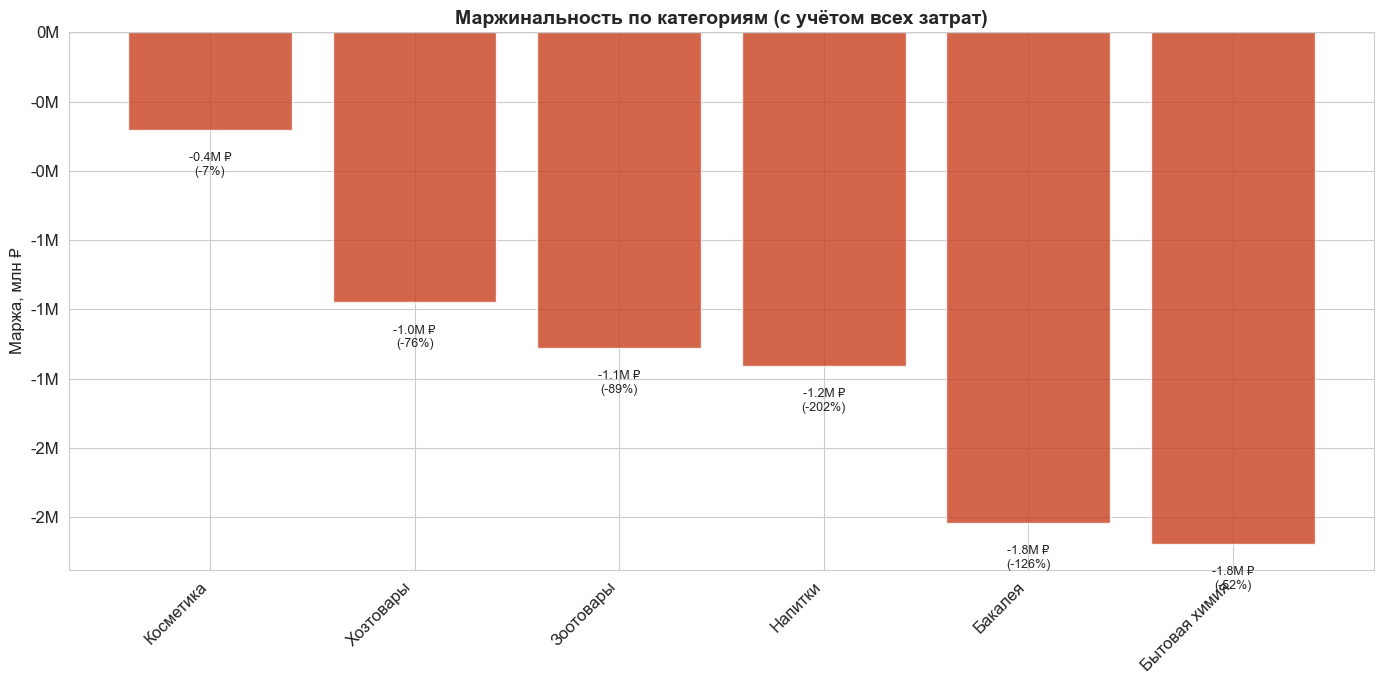


Структура затрат по категориям:
     category  revenue_gross  cost_of_goods  logistics  discount  return_loss     margin  cost_of_goods_pct  logistics_pct  discount_pct  return_loss_pct
    Косметика      5,424,284      3,514,174  1,648,768   282,888      331,639   -353,185                 65             30             5                6
    Хозтовары      1,442,090        957,300  1,293,769    73,783       91,816   -974,578                 66             90             5                6
    Зоотовары      1,439,025        973,313  1,441,979    73,035       88,829 -1,138,131                 68            100             5                6
      Напитки        667,728        453,488  1,345,731    34,095       38,005 -1,203,590                 68            202             5                6
      Бакалея      1,571,542      1,060,572  2,110,516    81,523       88,087 -1,769,155                 68            134             5                6
Бытовая химия      3,992,790      2,794,831

In [8]:
cat_margin = sales.groupby("category", observed=False).agg(
    revenue_gross=("revenue_gross", "sum"),
    revenue_net=("revenue_net", "sum"),
    cost_of_goods=("cost_of_goods", "sum"),
    logistics=("logistics_total", "sum"),
    discount=("discount_amount", "sum"),
    return_loss=("return_loss", "sum"),
    margin=("margin_absolute", "sum"),
    items_sold=("product_id", "count"),
    unique_products=("product_id", "nunique"),
).reset_index()

cat_margin["margin_pct"] = (cat_margin["margin"] / cat_margin["revenue_net"] * 100).round(1)
cat_margin["logistics_pct"] = (cat_margin["logistics"] / cat_margin["revenue_gross"] * 100).round(1)
cat_margin["return_pct"] = (cat_margin["return_loss"] / cat_margin["revenue_gross"] * 100).round(1)
cat_margin = cat_margin.sort_values("margin", ascending=False)

print(cat_margin[["category", "revenue_gross", "margin", "margin_pct", "logistics_pct", "return_pct"]].to_string(index=False))

# График
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(cat_margin))
bars = ax.bar(x, cat_margin["margin"] / 1_000_000, color=[
    COLORS["profit"] if v >= 0 else COLORS["loss"] for v in cat_margin["margin"]
], alpha=0.8)

# Добавляю подписи значений
for i, (bar, val, pct) in enumerate(zip(bars, cat_margin["margin"], cat_margin["margin_pct"])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., 
            height + (0.02 if height >= 0 else -0.08),
            f'{val/1_000_000:.1f}M ₽\n({pct:.0f}%)',
            ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cat_margin["category"], rotation=45, ha="right")
ax.set_ylabel("Маржа, млн ₽")
ax.set_title("Маржинальность по категориям (с учётом всех затрат)", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

plt.tight_layout()
plt.show()

# Детализация затрат по категориям
print("\nСтруктура затрат по категориям:")
cost_breakdown = cat_margin[["category", "revenue_gross", "cost_of_goods", "logistics", "discount", "return_loss", "margin"]].copy()
for col in ["cost_of_goods", "logistics", "discount", "return_loss"]:
    cost_breakdown[col + "_pct"] = (cost_breakdown[col] / cost_breakdown["revenue_gross"] * 100).round(1)
print(cost_breakdown.to_string(index=False))

### 3.2. Сравнение FBO vs FBS


Сводка по типам складов:
warehouse_type  revenue_gross     margin  items_sold  logistics_per_unit  margin_pct
           FBO      9,688,013 -5,660,340       34126                 266         -58
           FBS      4,849,446 -1,624,772       24538                 106         -34


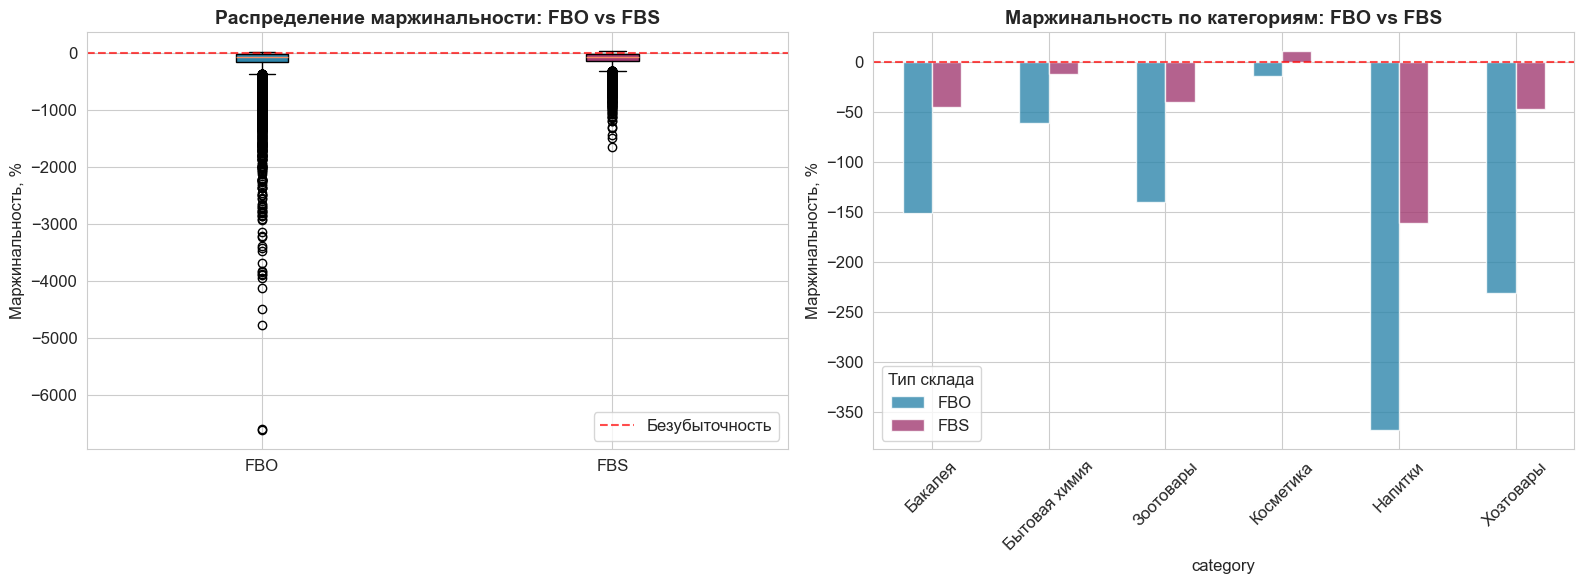

In [9]:
wh_margin = sales.groupby(["warehouse_type", "category"], observed=False).agg(
    revenue_gross=("revenue_gross", "sum"),
    revenue_net=("revenue_net", "sum"),
    cost_of_goods=("cost_of_goods", "sum"),
    logistics=("logistics_total", "sum"),
    margin=("margin_absolute", "sum"),
    items_sold=("product_id", "count"),
).reset_index()

wh_margin["margin_pct"] = (wh_margin["margin"] / wh_margin["revenue_net"] * 100).round(1)
wh_margin["logistics_per_unit"] = (wh_margin["logistics"] / wh_margin["items_sold"]).round(0)

# Сводка по типам складов
wh_summary = wh_margin.groupby("warehouse_type", observed=False).agg(
    revenue_gross=("revenue_gross", "sum"),
    margin=("margin", "sum"),
    items_sold=("items_sold", "sum"),
    logistics_per_unit=("logistics_per_unit", "mean"),
).reset_index()
wh_summary["margin_pct"] = (wh_summary["margin"] / wh_summary["revenue_gross"] * 100).round(1)

print("\nСводка по типам складов:")
print(wh_summary.to_string(index=False))

# График — boxplot маржинальности
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
fbo_margins = sales[sales["warehouse_type"] == "FBO"]["margin_pct"].dropna()
fbs_margins = sales[sales["warehouse_type"] == "FBS"]["margin_pct"].dropna()
box_data = [fbo_margins, fbs_margins]
bp = axes[0].boxplot(box_data, labels=["FBO", "FBS"], patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS["primary"])
bp['boxes'][1].set_facecolor(COLORS["secondary"])
axes[0].axhline(y=0, color="red", linestyle="--", alpha=0.7, label="Безубыточность")
axes[0].set_ylabel("Маржинальность, %")
axes[0].set_title("Распределение маржинальности: FBO vs FBS", fontsize=14, fontweight="bold")
axes[0].legend()

# Столбчатая диаграмма по категориям
pivot = wh_margin.pivot(index="category", columns="warehouse_type", values="margin_pct")
pivot.plot(kind="bar", ax=axes[1], color=[COLORS["primary"], COLORS["secondary"]], alpha=0.8)
axes[1].axhline(y=0, color="red", linestyle="--", alpha=0.7)
axes[1].set_ylabel("Маржинальность, %")
axes[1].set_title("Маржинальность по категориям: FBO vs FBS", fontsize=14, fontweight="bold")
axes[1].legend(title="Тип склада")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.3. Топ-10 прибыльных и убыточных товаров


Топ-10 самых прибыльных товаров:
  1. Nivea шампунь 445мл                                     | Кат: Косметика    | Маржа: 9,059 ₽ | Продано: 46 шт | Марж-ть: 26%
  2. L'Oreal крем для лица 144мл                             | Кат: Косметика    | Маржа: 7,600 ₽ | Продано: 52 шт | Марж-ть: 21%
  3. L'Oreal тональный крем 268мл                            | Кат: Косметика    | Маржа: 6,412 ₽ | Продано: 71 шт | Марж-ть: 13%
  4. Nivea маска для лица 338мл                              | Кат: Косметика    | Маржа: 6,356 ₽ | Продано: 61 шт | Марж-ть: 13%
  5. Чистая Линия гель для душа 405мл                        | Кат: Косметика    | Маржа: 5,552 ₽ | Продано: 55 шт | Марж-ть: 13%
  6. Maybelline тональный крем 253мл                         | Кат: Косметика    | Маржа: 5,287 ₽ | Продано: 58 шт | Марж-ть: 11%
  7. Bourjois тушь для ресниц 272мл                          | Кат: Косметика    | Маржа: 4,972 ₽ | Продано: 32 шт | Марж-ть: 21%
  8. Bourjois тушь для ресниц 377мл                     

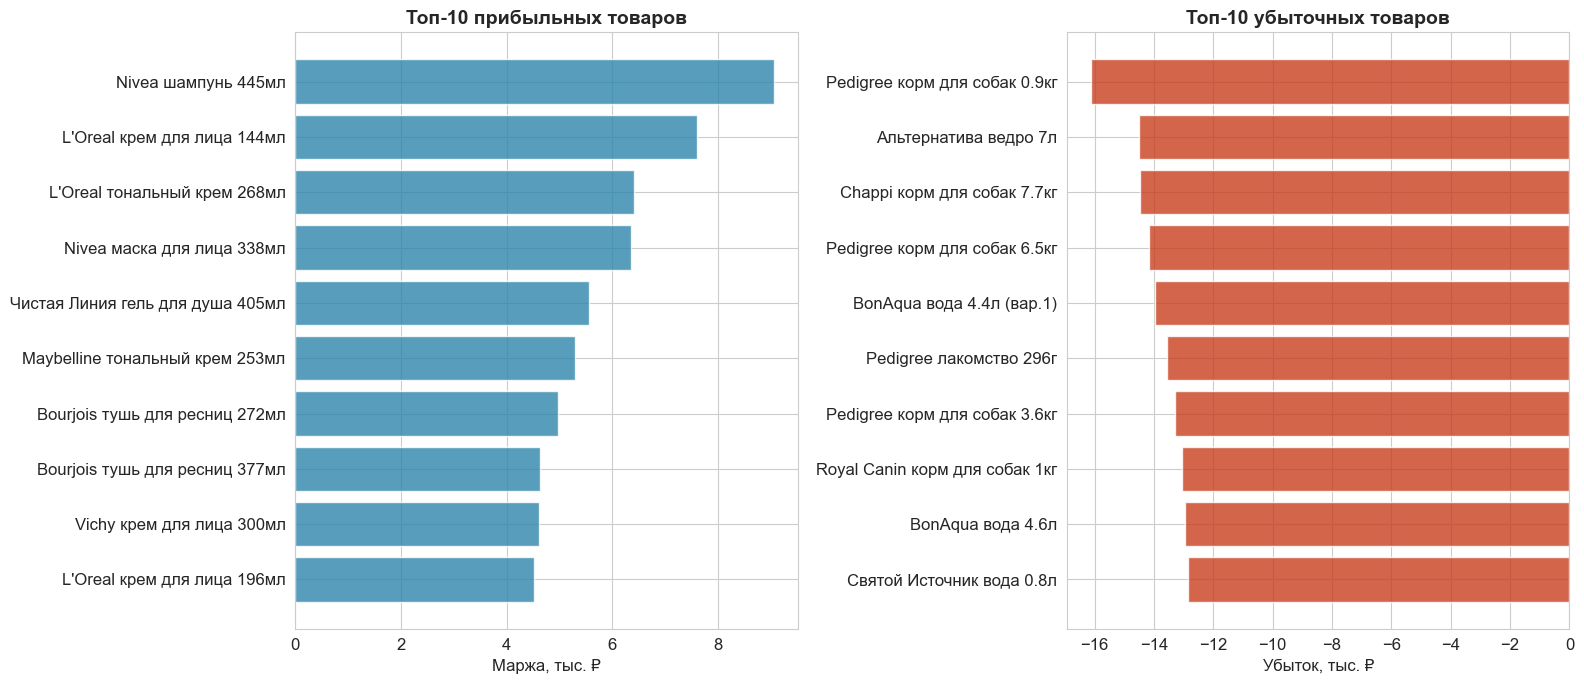

In [10]:
product_margin = sales.groupby(["product_id", "category"], observed=False).agg(
    revenue_gross=("revenue_gross", "sum"),
    revenue_net=("revenue_net", "sum"),
    margin=("margin_absolute", "sum"),
    items_sold=("product_id", "count"),
    avg_margin_pct=("margin_pct", "mean"),
).reset_index()

product_margin = product_margin.merge(
    products[["product_id", "product_name"]], on="product_id"
)

# Топ-10 прибыльных
top10_profit = product_margin.sort_values("margin", ascending=False).head(10)
print("\nТоп-10 самых прибыльных товаров:")
for i, (_, row) in enumerate(top10_profit.iterrows(), 1):
    print(f"  {i}. {row['product_name'][:55]:<55} | Кат: {row['category']:<12} | "
          f"Маржа: {row['margin']:,.0f} ₽ | Продано: {row['items_sold']} шт | "
          f"Марж-ть: {row['avg_margin_pct']:.0f}%")

# Топ-10 убыточных
top10_loss = product_margin.sort_values("margin", ascending=True).head(10)
print("\nТоп-10 самых убыточных товаров:")
for i, (_, row) in enumerate(top10_loss.iterrows(), 1):
    print(f"  {i}. {row['product_name'][:55]:<55} | Кат: {row['category']:<12} | "
          f"Убыток: {row['margin']:,.0f} ₽ | Продано: {row['items_sold']} шт | "
          f"Марж-ть: {row['avg_margin_pct']:.0f}%")

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Топ-10 прибыльных
axes[0].barh(top10_profit["product_name"].str.slice(0, 50)[::-1], 
             top10_profit["margin"][::-1] / 1000,
             color=COLORS["profit"], alpha=0.8)
axes[0].set_xlabel("Маржа, тыс. ₽")
axes[0].set_title("Топ-10 прибыльных товаров", fontsize=14, fontweight="bold")

# Топ-10 убыточных
axes[1].barh(top10_loss["product_name"].str.slice(0, 50)[::-1], 
             top10_loss["margin"][::-1] / 1000,
             color=COLORS["loss"], alpha=0.8)
axes[1].set_xlabel("Убыток, тыс. ₽")
axes[1].set_title("Топ-10 убыточных товаров", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 3.4. Распределение маржинальности

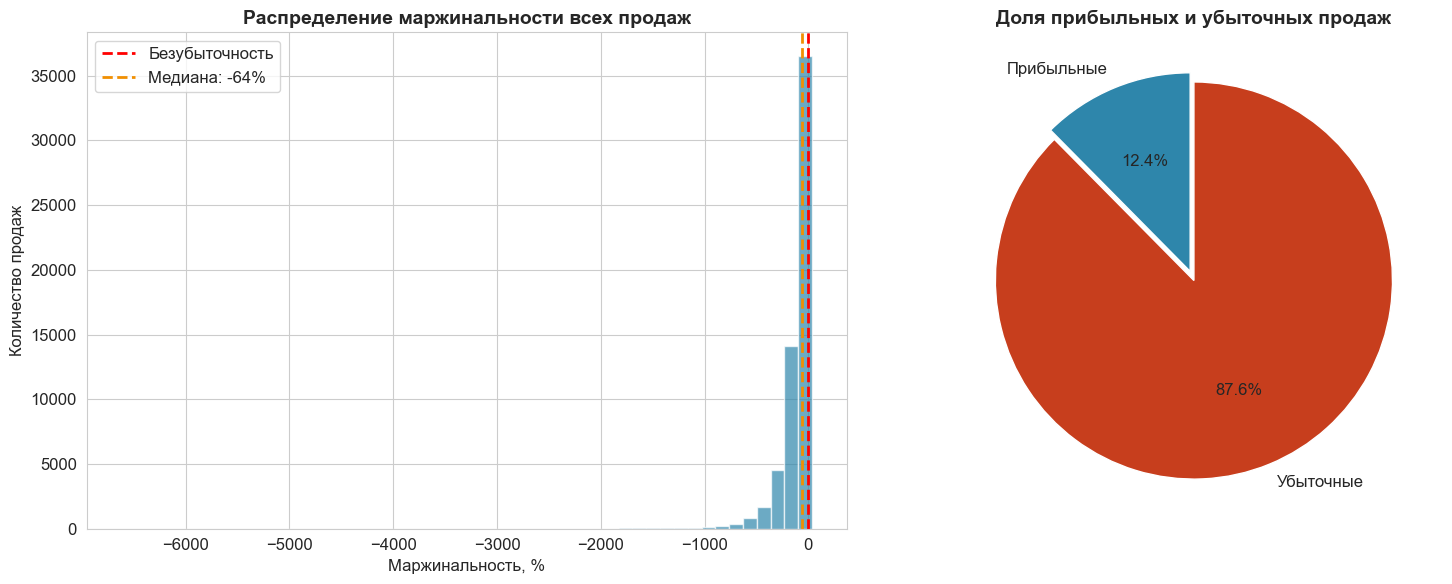


Прибыльных продаж: 7,280 (12.4%)
  Суммарная маржа: 487,442 ₽
  Средняя маржинальность: 12%

Убыточных продаж: 51,384 (87.6%)
  Суммарный убыток: -7,772,554 ₽
  Средняя маржинальность: -134%


In [11]:
# Общее распределение
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма
axes[0].hist(sales["margin_pct"].dropna(), bins=50, color=COLORS["primary"], 
             alpha=0.7, edgecolor="white")
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=2, label="Безубыточность")
axes[0].axvline(x=sales["margin_pct"].median(), color=COLORS["accent"], 
                linestyle="--", linewidth=2, label=f"Медиана: {sales['margin_pct'].median():.0f}%")
axes[0].set_xlabel("Маржинальность, %")
axes[0].set_ylabel("Количество продаж")
axes[0].set_title("Распределение маржинальности всех продаж", fontsize=14, fontweight="bold")
axes[0].legend()

# Доля прибыльных vs убыточных
profit_mask = sales["margin_absolute"] > 0
profit_summary = pd.DataFrame({
    "Тип": ["Прибыльные", "Убыточные"],
    "Строк": [profit_mask.sum(), (~profit_mask).sum()],
    "Выручка нетто": [
        sales.loc[profit_mask, "revenue_net"].sum(),
        sales.loc[~profit_mask, "revenue_net"].sum()
    ],
    "Маржа": [
        sales.loc[profit_mask, "margin_absolute"].sum(),
        sales.loc[~profit_mask, "margin_absolute"].sum()
    ]
})

axes[1].pie(profit_summary["Строк"], labels=profit_summary["Тип"], 
            autopct="%1.1f%%", colors=[COLORS["profit"], COLORS["loss"]], 
            startangle=90, explode=(0.05, 0))
axes[1].set_title("Доля прибыльных и убыточных продаж", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nПрибыльных продаж: {profit_mask.sum():,} ({profit_mask.sum()/len(sales)*100:.1f}%)")
print(f"  Суммарная маржа: {sales.loc[profit_mask, 'margin_absolute'].sum():,.0f} ₽")
print(f"  Средняя маржинальность: {sales.loc[profit_mask, 'margin_pct'].mean():.0f}%")
print(f"\nУбыточных продаж: {(~profit_mask).sum():,} ({(~profit_mask).sum()/len(sales)*100:.1f}%)")
print(f"  Суммарный убыток: {sales.loc[~profit_mask, 'margin_absolute'].sum():,.0f} ₽")
print(f"  Средняя маржинальность: {sales.loc[~profit_mask, 'margin_pct'].mean():.0f}%")

### Выводы по маржинальному анализу

**Маржинальность по категориям:**
- **Все 6 категорий убыточны.** Даже лучшая категория — Косметика — показывает −7.3% маржинальности.
- Основная причина — **логистика:** в категориях Напитки и Бакалея затраты на логистику превышают выручку (201% и 134% соответственно). Это означает, что каждый проданный товар в этих категориях приносит не прибыль, а прямой убыток.
- Себестоимость товаров составляет 64–70% от выручки — это нормально для e-commerce. Проблема не в закупочных ценах, а в **избыточных логистических затратах**.

**FBO vs FBS:**
- **FBS выгоднее FBO в 1.7 раза** (−33.5% vs −58.4% маржинальности).
- Логистика на единицу: FBO — 266 ₽, FBS — 106 ₽. Разница в 160 ₽ — это стоимость хранения на складе маркетплейса.
- FBO используется для 58% продаж, но генерирует 78% убытков. **Перевод части товаров на FBS может сократить потери.**
- Исключение: Косметика на FBO показывает менее отрицательную маржинальность, чем другие категории — для дорогих товаров с высокой оборачиваемостью FBO может быть оправдан.

**Топ-10 товаров:**
- **Все 10 прибыльных товаров — Косметика** (кремы, шампуни, тональные средства). Маржинальность 7–26%, средняя прибыль 5–9 тыс. ₽ на товар за 2 года.
- **Главные убыточные товары — корма для животных и вода.** Маржинальность от −151% до −457%. Это низкомаржинальные товары с высоким весом/объёмом — их доставка и хранение стоят дороже, чем они сами.
- Характерно, что все топ-10 прибыльных товаров имеют небольшой вес и объём, а все топ-10 убыточных — крупногабаритные или тяжёлые.

**Распределение маржинальности:**
- **87.6% продаж убыточны** (51 384 из 58 664). Суммарный убыток по ним: −7.8 млн ₽.
- **12.4% продаж прибыльны** (7 280). Суммарная прибыль: +0.49 млн ₽.
- Средняя маржинальность прибыльных продаж: +12%. Средняя маржинальность убыточных: −134%.
- Проблема не в том, что нет прибыльных товаров — они есть. Проблема в том, что **убыточных продаж в 7 раз больше, и убыток по каждой из них в 11 раз больше прибыли.**

**Ключевой вывод:**
Бизнес теряет деньги не из-за плохих наценок, а из-за **несоразмерных логистических затрат**. Хранение на складе маркетплейса и доставка крупногабаритных/тяжёлых товаров «съедают» всю маржу. В следующих разделах я проанализирую влияние скидок и возвратов на маржинальность и дам конкретные рекомендации.

---

## 4. Анализ скидок

Скидки — палка о двух концах. С одной стороны, они стимулируют продажи и помогают распродавать неликвиды. С другой — «съедают» маржу и могут делать прибыльные товары убыточными.

В этом разделе я исследую:
- Как распределены скидки по категориям?
- Есть ли системность в скидках или они хаотичны?
- Сколько товаров без скидки были бы прибыльными, но со скидкой уходят в минус?
- Какие категории больше всего теряют от скидок?

### 4.1. Распределение скидок по категориям

     category  discount_share_items  avg_discount_pct  total_discount  discount_share_revenue
Бытовая химия                    41                 6         212,124                       5
      Бакалея                    41                 6          81,523                       5
    Косметика                    41                 6         282,888                       5
    Зоотовары                    40                 6          73,035                       5
      Напитки                    40                 6          34,095                       5
    Хозтовары                    40                 6          73,783                       5


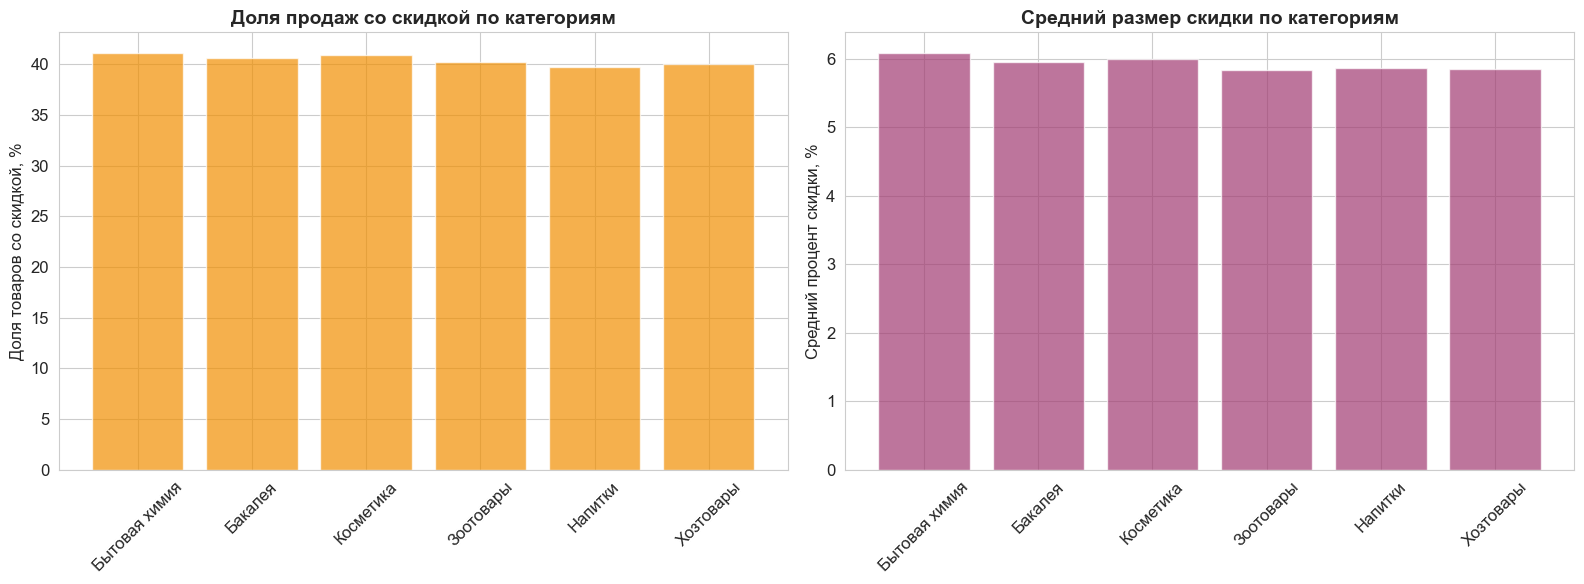


Общая сумма скидок: 757,447 ₽
Доля выручки, потерянной в скидках: 5.2%


In [12]:
# Считаю долю продаж со скидкой и без
discount_stats = sales.groupby("category", observed=False).agg(
    total_items=("product_id", "count"),
    items_with_discount=("discount_pct", lambda x: (x > 0).sum()),
    total_discount=("discount_amount", "sum"),
    avg_discount_pct=("discount_pct", "mean"),
    revenue_gross=("revenue_gross", "sum"),
).reset_index()

discount_stats["discount_share_items"] = (discount_stats["items_with_discount"] / discount_stats["total_items"] * 100).round(1)
discount_stats["discount_share_revenue"] = (discount_stats["total_discount"] / discount_stats["revenue_gross"] * 100).round(1)
discount_stats = discount_stats.sort_values("discount_share_revenue", ascending=False)

print(discount_stats[["category", "discount_share_items", "avg_discount_pct", 
                       "total_discount", "discount_share_revenue"]].to_string(index=False))

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Доля товаров со скидкой по категориям
axes[0].bar(discount_stats["category"], discount_stats["discount_share_items"], 
            color=COLORS["accent"], alpha=0.7)
axes[0].set_ylabel("Доля товаров со скидкой, %")
axes[0].set_title("Доля продаж со скидкой по категориям", fontsize=14, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# Средний процент скидки по категориям
axes[1].bar(discount_stats["category"], discount_stats["avg_discount_pct"], 
            color=COLORS["secondary"], alpha=0.7)
axes[1].set_ylabel("Средний процент скидки, %")
axes[1].set_title("Средний размер скидки по категориям", fontsize=14, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"\nОбщая сумма скидок: {discount_stats['total_discount'].sum():,.0f} ₽")
print(f"Доля выручки, потерянной в скидках: {discount_stats['total_discount'].sum() / discount_stats['revenue_gross'].sum() * 100:.1f}%")

### 4.2. Влияние скидок на маржинальность

In [13]:
# Сравниваю маржинальность товаров со скидкой и без
sales["has_discount"] = sales["discount_pct"] > 0

discount_margin = sales.groupby("has_discount").agg(
    items=("product_id", "count"),
    revenue_net=("revenue_net", "sum"),
    margin=("margin_absolute", "sum"),
    avg_margin_pct=("margin_pct", "mean"),
).reset_index()

discount_margin["margin_share"] = (discount_margin["margin"] / discount_margin["margin"].sum() * 100).round(1)
print(discount_margin.to_string(index=False))

# Сколько товаров стали бы прибыльными без скидки?
# Считаю маржу без учёта скидки (но с логистикой и возвратами)
sales["margin_without_discount"] = (
    sales["margin_absolute"] + sales["discount_amount"]
)
sales["margin_pct_without_discount"] = (
    sales["margin_without_discount"] / (sales["revenue_net"] + sales["discount_amount"]) * 100
).round(1)
sales["margin_pct_without_discount"].replace([np.inf, -np.inf], np.nan, inplace=True)

# Товары, которые убыточны сейчас, но были бы прибыльны без скидки
rescued = sales[(sales["margin_absolute"] < 0) & (sales["margin_without_discount"] > 0)]
print(f"\nТоваров, которые были бы прибыльны без скидки: {len(rescued)} ({len(rescued)/len(sales)*100:.1f}%)")
print(f"  Их текущий убыток: {rescued['margin_absolute'].sum():,.0f} ₽")
print(f"  Их потенциальная прибыль (без скидки): {rescued['margin_without_discount'].sum():,.0f} ₽")

# Детализация: группирую по размеру скидки
sales["discount_bucket"] = pd.cut(
    sales["discount_pct"], 
    bins=[-1, 0, 5, 10, 20, 50], 
    labels=["Без скидки", "1-5%", "6-10%", "11-20%", "21-50%"]
)

bucket_stats = sales.groupby("discount_bucket", observed=False).agg(
    items=("product_id", "count"),
    avg_margin_pct=("margin_pct", "mean"),
    total_margin=("margin_absolute", "sum"),
    avg_margin_without=("margin_pct_without_discount", "mean"),
).reset_index()

print("\nМаржинальность по уровню скидки:")
print(bucket_stats.to_string(index=False))

 has_discount  items  revenue_net     margin  avg_margin_pct  margin_share
        False  34916    8,603,891 -3,385,720             -86            46
         True  23748    4,291,447 -3,899,392            -161            54

Товаров, которые были бы прибыльны без скидки: 1223 (2.1%)
  Их текущий убыток: -44,600 ₽
  Их потенциальная прибыль (без скидки): 31,211 ₽

Маржинальность по уровню скидки:
discount_bucket  items  avg_margin_pct  total_margin  avg_margin_without
     Без скидки  34916             -86    -3,385,720                 -86
           1-5%   1356             -95      -158,865                 -85
          6-10%   6697            -116      -901,935                 -98
         11-20%  10154            -154    -1,674,535                -114
         21-50%   5541            -244    -1,164,058                -148


### 4.3. Системность vs хаотичность скидок

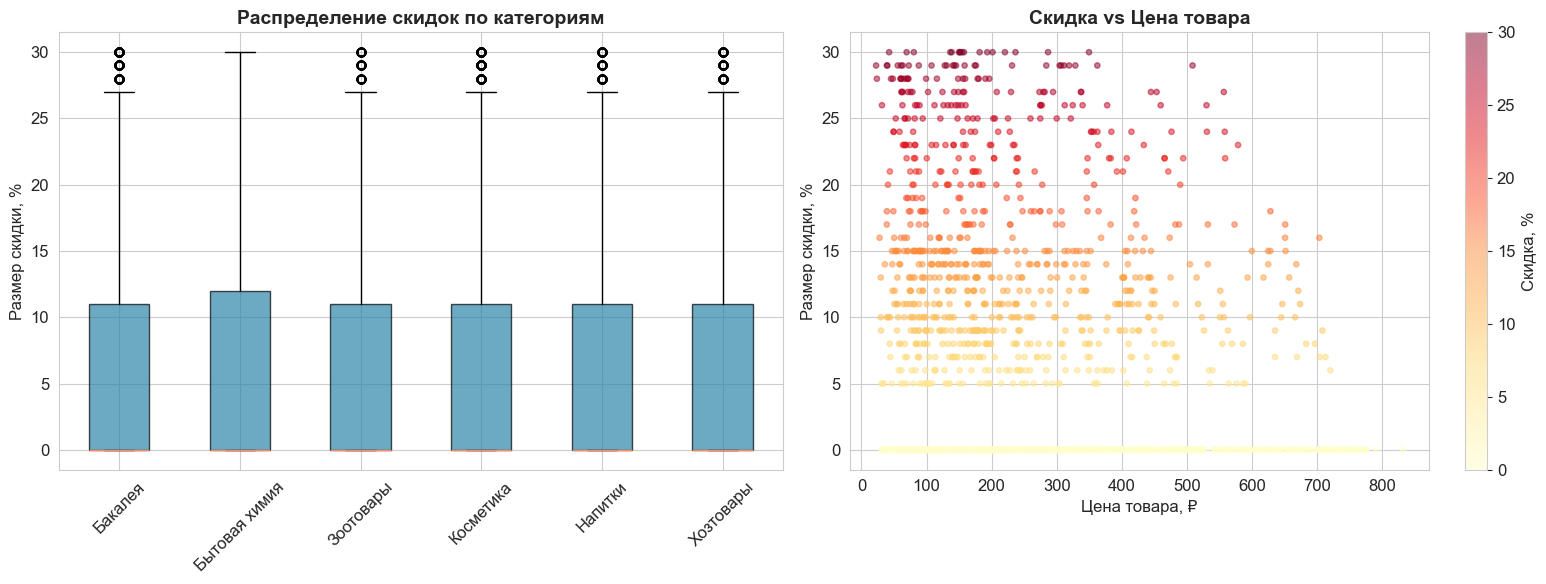


Товаров с ≥5 продажами: 2454
  Из них со скидками: 2422
  Системные скидки (постоянный %): 35
  Хаотичные скидки (разный %): 2387


In [14]:
# Анализирую, насколько скидки зависят от категории и цены товара
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Распределение скидок по категориям (boxplot)
categories_unique = sorted(sales["category"].dropna().unique())
cat_discount_data = [sales[sales["category"] == cat]["discount_pct"].dropna() 
                     for cat in categories_unique]
bp = axes[0].boxplot(cat_discount_data, labels=categories_unique, patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor(COLORS["primary"])
    box.set_alpha(0.7)
axes[0].set_ylabel("Размер скидки, %")
axes[0].set_title("Распределение скидок по категориям", fontsize=14, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# Скидка vs цена товара (scatter)
sample = sales.sample(2000, random_state=42)
scatter = axes[1].scatter(sample["unit_price"], sample["discount_pct"], 
                          c=sample["discount_pct"], cmap="YlOrRd", 
                          alpha=0.5, s=15)
axes[1].set_xlabel("Цена товара, ₽")
axes[1].set_ylabel("Размер скидки, %")
axes[1].set_title("Скидка vs Цена товара", fontsize=14, fontweight="bold")
plt.colorbar(scatter, ax=axes[1], label="Скидка, %")

plt.tight_layout()
plt.show()

# Есть ли товары, где скидка всегда одинаковая? (признак системной акции)
discount_consistency = sales.groupby("product_id")["discount_pct"].agg(["mean", "std", "count"])
discount_consistency = discount_consistency[discount_consistency["count"] >= 5]
discount_consistency["is_systematic"] = discount_consistency["std"] < 2

systematic_count = discount_consistency["is_systematic"].sum()
total_with_discount = (discount_consistency["mean"] > 0).sum()
print(f"\nТоваров с ≥5 продажами: {len(discount_consistency)}")
print(f"  Из них со скидками: {total_with_discount}")
print(f"  Системные скидки (постоянный %): {systematic_count}")
print(f"  Хаотичные скидки (разный %): {total_with_discount - systematic_count}")

### Выводы по анализу скидок

**Масштаб скидок:**
- Общая сумма скидок за 2 года — **757 тыс. ₽ (5.2% от выручки)**. В среднем каждый товар со скидкой теряет 6% от цены.
- Доля продаж со скидкой — **40%** (23 748 из 58 664). Скидки применяются активно и равномерно по всем категориям.
- Средний процент скидки одинаков для всех категорий — **6%**. Нет категорий-«любимчиков» для акций.

**Влияние на маржу:**
- Продажи без скидки убыточны на −86% в среднем. Продажи со скидкой — на −161%. **Скидка почти удваивает убыток.**
- Из 23 748 товаров со скидкой **1 223 товара могли бы быть прибыльными без неё** (+31 тыс. ₽ потенциальной прибыли вместо −45 тыс. ₽ убытка).
- С ростом размера скидки маржинальность резко падает:
  - Без скидки: −86%
  - Скидка 1–5%: −95%
  - Скидка 6–10%: −116%
  - Скидка 11–20%: −154%
  - **Скидка 21–50%: −244%** — это уже не стимулирование, а раздача товаров ниже себестоимости.
- В группе «21–50%» 5 541 продажа — почти 10% всего объёма. Это зона прямых потерь.

**Системность скидок:**
- Из 2 454 товаров с ≥5 продажами скидки применяются к 2 422.
- **Только 35 товаров имеют системные скидки** (постоянный, предсказуемый процент). Остальные 2 387 — **хаотичные** (каждый раз разный процент).
- Это означает, что скидки назначаются вручную, без оглядки на маржинальность товара. Менеджеры «дают скидку», не проверяя, уйдёт ли товар в минус.

**Рекомендации:**
- **Запретить скидки выше 10%** без согласования — это сразу сократит убытки по группе «11–50%» (15 695 продаж).
- **Внедрить правило «стоп-маржи»:** если скидка делает товар убыточным — она не применяется. Это спасёт те 1 223 товара, которые прибыльны без скидки.
- **Перевести скидки на системную основу:** фиксированные проценты для плановых акций, запрет на ручные скидки без расчёта маржи.
- Потенциальный эффект от наведения порядка со скидками: **сокращение убытков на ~1–1.5 млн ₽/год.**
---

## 5. Возвраты и их влияние на маржу

Возвраты — неизбежная часть e-commerce, но их влияние на прибыль часто недооценивают. Потери от возврата включают не только возвращённые деньги клиенту, но и:

- **Стоимость обратной логистики** (доставка от ПВЗ обратно на склад)
- **Утилизацию** испорченных товаров (потеря себестоимости)
- **Упущенную выгоду** от невозможности продать товар, пока он в пути

В этом разделе я оцениваю реальную стоимость возвратов для бизнеса и показываю, какие категории страдают больше всего.

### 5.1. Потери от возвратов по категориям

     category  total_returns  total_loss  disposals  disposal_rate  avg_loss_per_return
    Косметика            756     412,224        229             30                  545
Бытовая химия            736     323,099        204             28                  439
      Бакалея            650     159,963        197             30                  246
    Хозтовары            511     159,806        149             29                  313
    Зоотовары            339     129,578        104             31                  382
      Напитки            527     106,756        159             30                  203


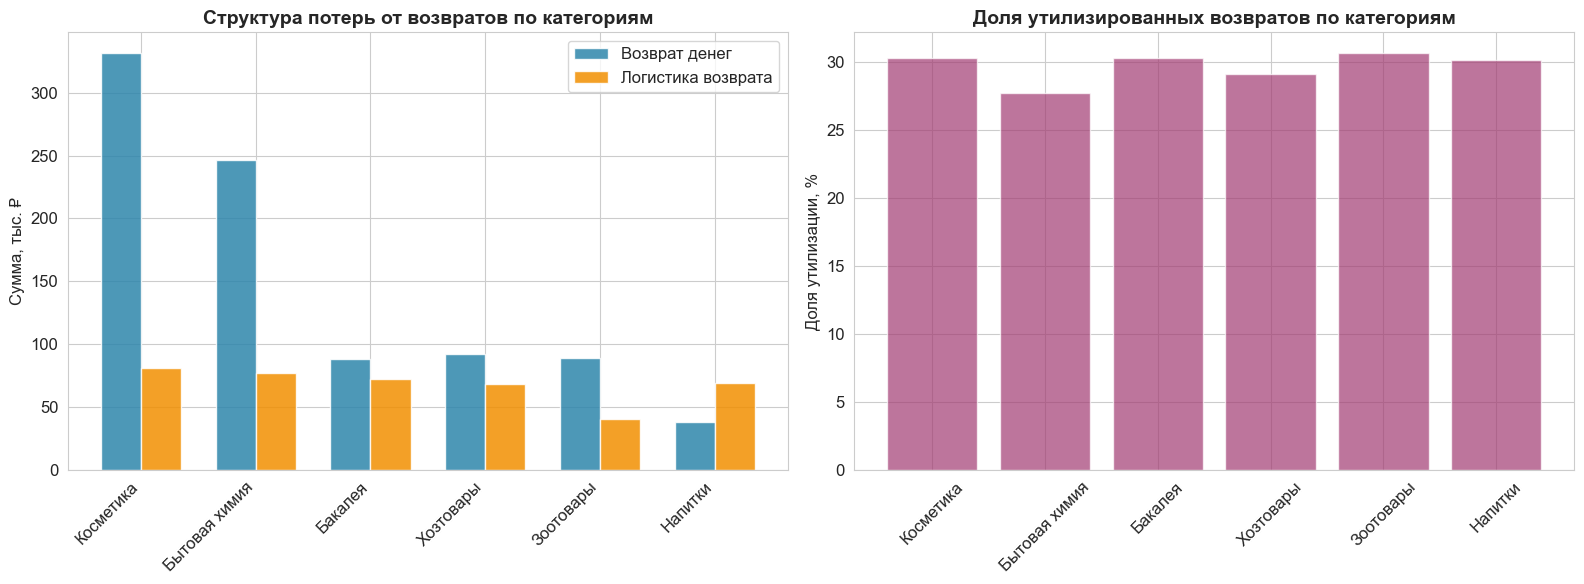


Общие потери от возвратов: 1,291,425 ₽
  Возврат денег: 884,673 ₽
  Логистика возврата: 406,752 ₽
  Средние потери на 1 возврат: 367 ₽


In [15]:
# Анализ возвратов: сумма возвратов + стоимость обратной логистики + утилизация
returns_detail = returns.copy()

# Присоединяю категорию товара
returns_detail = returns_detail.merge(
    products[["product_id", "category"]], on="product_id", how="left"
)

# Потери по категориям
return_loss_by_cat = returns_detail.groupby("category", observed=False).agg(
    total_returns=("return_id", "count"),
    refund_amount=("refund_amount", "sum"),
    return_logistics=("return_logistics_cost", "sum"),
    disposals=("return_status", lambda x: (x == "Утилизация").sum()),
    disposal_rate=("return_status", lambda x: (x == "Утилизация").mean() * 100),
).reset_index()

return_loss_by_cat["total_loss"] = return_loss_by_cat["refund_amount"] + return_loss_by_cat["return_logistics"]
return_loss_by_cat["avg_loss_per_return"] = (return_loss_by_cat["total_loss"] / return_loss_by_cat["total_returns"]).round(0)
return_loss_by_cat = return_loss_by_cat.sort_values("total_loss", ascending=False)

print(return_loss_by_cat[["category", "total_returns", "total_loss", "disposals", 
                           "disposal_rate", "avg_loss_per_return"]].to_string(index=False))

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Столбчатая диаграмма потерь — контрастные цвета
x = range(len(return_loss_by_cat))
width = 0.35
axes[0].bar([i - width/2 for i in x], return_loss_by_cat["refund_amount"] / 1000, width,
            color="#2E86AB", alpha=0.85, label="Возврат денег")
axes[0].bar([i + width/2 for i in x], return_loss_by_cat["return_logistics"] / 1000, width,
            color="#F18F01", alpha=0.85, label="Логистика возврата")
axes[0].set_xticks(x)
axes[0].set_xticklabels(return_loss_by_cat["category"], rotation=45, ha="right")
axes[0].set_ylabel("Сумма, тыс. ₽")
axes[0].set_title("Структура потерь от возвратов по категориям", fontsize=14, fontweight="bold")
axes[0].legend()

# Доля утилизации по категориям
axes[1].bar(return_loss_by_cat["category"], return_loss_by_cat["disposal_rate"],
            color="#A23B72", alpha=0.7)
axes[1].set_ylabel("Доля утилизации, %")
axes[1].set_title("Доля утилизированных возвратов по категориям", fontsize=14, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"\nОбщие потери от возвратов: {return_loss_by_cat['total_loss'].sum():,.0f} ₽")
print(f"  Возврат денег: {return_loss_by_cat['refund_amount'].sum():,.0f} ₽")
print(f"  Логистика возврата: {return_loss_by_cat['return_logistics'].sum():,.0f} ₽")
print(f"  Средние потери на 1 возврат: {return_loss_by_cat['total_loss'].sum() / return_loss_by_cat['total_returns'].sum():,.0f} ₽")

### 5.2. Маржинальность до и после учёта возвратов

     category  margin_pct_with  margin_pct_without  return_impact
    Косметика               -6                  -0             -6
    Хозтовары              -68                 -61             -6
    Зоотовары              -79                 -73             -6
      Напитки             -180                -175             -6
      Бакалея             -113                -107             -6
Бытовая химия              -46                 -40             -6


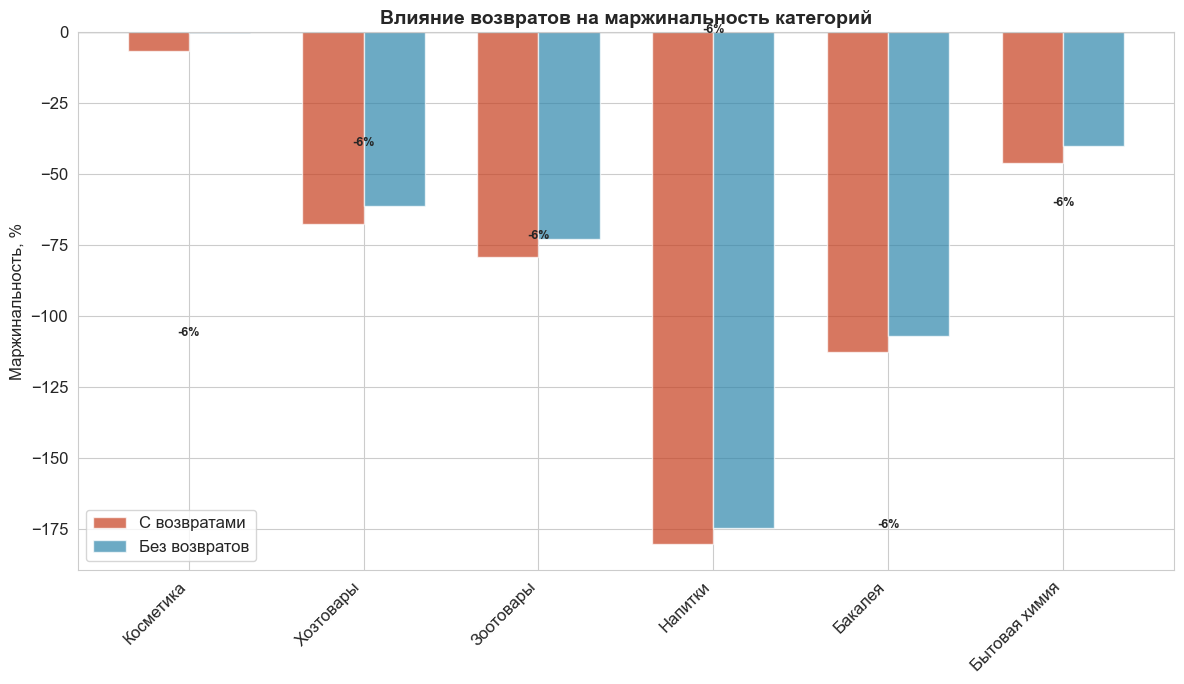

In [16]:
# Считаю маржинальность без учёта возвратов для сравнения
cat_comparison = cat_margin[["category", "revenue_gross", "margin"]].copy()
cat_comparison.columns = ["category", "revenue_gross", "margin_with_returns"]

# Маржа без возвратов = текущая маржа + return_loss
cat_comparison["margin_without_returns"] = (
    cat_comparison["margin_with_returns"] + cat_margin["return_loss"]
)
cat_comparison["margin_pct_with"] = (cat_comparison["margin_with_returns"] / cat_comparison["revenue_gross"] * 100).round(1)
cat_comparison["margin_pct_without"] = (cat_comparison["margin_without_returns"] / cat_comparison["revenue_gross"] * 100).round(1)
cat_comparison["return_impact"] = (cat_comparison["margin_pct_with"] - cat_comparison["margin_pct_without"]).round(1)

print(cat_comparison[["category", "margin_pct_with", "margin_pct_without", "return_impact"]].to_string(index=False))

# График — сравнение маржинальности до и после возвратов
fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(cat_comparison))
width = 0.35
ax.bar([i - width/2 for i in x], cat_comparison["margin_pct_with"], width,
       color=COLORS["loss"], alpha=0.7, label="С возвратами")
ax.bar([i + width/2 for i in x], cat_comparison["margin_pct_without"], width,
       color=COLORS["profit"], alpha=0.7, label="Без возвратов")
ax.set_xticks(x)
ax.set_xticklabels(cat_comparison["category"], rotation=45, ha="right")
ax.set_ylabel("Маржинальность, %")
ax.set_title("Влияние возвратов на маржинальность категорий", fontsize=14, fontweight="bold")
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.8)

# Добавляю разницу на график
for i, row in cat_comparison.iterrows():
    diff = row["return_impact"]
    ax.annotate(f"{diff:.0f}%", xy=(i, max(row["margin_pct_with"], row["margin_pct_without"])),
                ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

### 5.3. Стоимость утилизации

Утилизировано товаров: 1042
  Потеря себестоимости: 179,489 ₽
  Логистика возврата: 119,731 ₽
  Общие потери от утилизации: 299,220 ₽
  Средние потери на 1 утилизацию: 287 ₽

Утилизация по причинам возврата:
                                       count  total_loss  avg_loss
return_reason                                                     
Передумал / не понравился                342      97,599       285
Не соответствует описанию / ожиданиям    284      82,406       290
Брак / повреждение товара                212      61,791       291
Повреждение при доставке                 110      30,531       278
Ошибка в заказе (не тот товар)            94      26,892       286


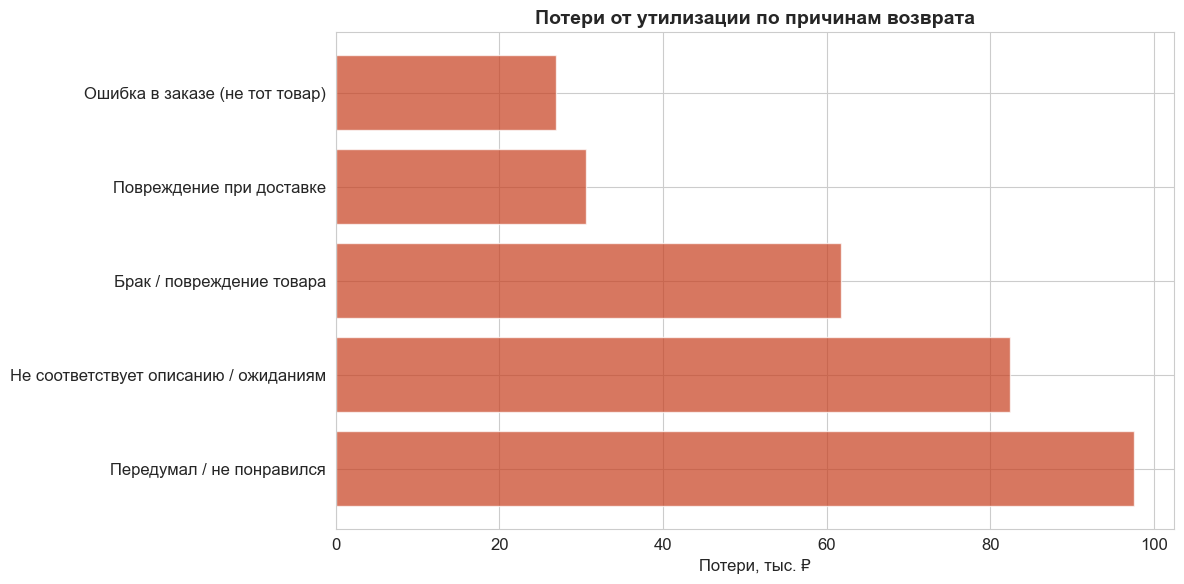

In [17]:
# Товары, которые были утилизированы — полная потеря себестоимости
disposals = returns_detail[returns_detail["return_status"] == "Утилизация"].copy()

# Присоединяю себестоимость
disposals = disposals.merge(
    products[["product_id", "base_cost"]], on="product_id", how="left"
)

# Потери от утилизации: себестоимость + логистика возврата
disposals["disposal_loss"] = disposals["base_cost"] + disposals["return_logistics_cost"]

print(f"Утилизировано товаров: {len(disposals)}")
print(f"  Потеря себестоимости: {disposals['base_cost'].sum():,.0f} ₽")
print(f"  Логистика возврата: {disposals['return_logistics_cost'].sum():,.0f} ₽")
print(f"  Общие потери от утилизации: {disposals['disposal_loss'].sum():,.0f} ₽")
print(f"  Средние потери на 1 утилизацию: {disposals['disposal_loss'].mean():,.0f} ₽")

# Утилизация по причинам возврата
disposal_by_reason = disposals.groupby("return_reason", observed=False).agg(
    count=("return_id", "count"),
    total_loss=("disposal_loss", "sum"),
    avg_loss=("disposal_loss", "mean"),
).sort_values("total_loss", ascending=False)

print("\nУтилизация по причинам возврата:")
print(disposal_by_reason.to_string())

# График
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(disposal_by_reason.index, disposal_by_reason["total_loss"] / 1000, 
        color=COLORS["loss"], alpha=0.7)
ax.set_xlabel("Потери, тыс. ₽")
ax.set_title("Потери от утилизации по причинам возврата", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Выводы по анализу возвратов

**Общие потери:**
- За 2 года возвраты обошлись бизнесу в **1.29 млн ₽**: 0.88 млн — возврат денег клиентам, 0.41 млн — стоимость обратной логистики.
- Это **8.9% от выручки нетто** — выше нормы для e-commerce (5–8%).
- **Средние потери на 1 возврат — 367 ₽**, что выше среднего чека (248 ₽). Один возврат съедает прибыль с нескольких успешных продаж.

**Потери по категориям:**
- **Косметика** — абсолютный лидер по потерям (412 тыс. ₽). Объём продаж большой, но и средний чек потерь самый высокий — 545 ₽ за возврат.
- **Напитки** имеют самый низкий средний чек потерь (203 ₽), но самую высокую долю утилизации (30%) — возвращённые напитки часто не подлежат повторной продаже.
- Доля утилизации **стабильна по всем категориям — 28–31%.** Это говорит о системной проблеме: примерно каждый третий возврат не попадает обратно в оборот.

**Влияние на маржинальность:**
- Возвраты ухудшают маржинальность всех категорий ровно на **6 п.п.** — влияние равномерное.
- Даже без возвратов все категории остаются убыточными. Возвраты — не первопричина убытков, но они **добавляют 1.29 млн ₽ к общему минусу.**

**Утилизация:**
- **1 042 товара утилизировано** на общую сумму ~300 тыс. ₽ (себестоимость + логистика).
- **Самая частая причина утилизации — «Передумал / не понравился» (342 случая).** Это означает, что товар физически не испорчен, но не может быть продан повторно. Вероятные причины:
  - Нарушена упаковка при вскрытии.
  - Товар из категории, не подлежащей возврату в оборот по санитарным нормам (косметика, гигиена).
  - Политика маркетплейса, запрещающая повторную продажу возвратов.
- Это зона для переговоров с маркетплейсом или изменения политики упаковки.
- **«Брак / повреждение товара»** — 212 случаев, 62 тыс. ₽ потерь. Здесь потери можно переложить на поставщика (если есть договор о качестве).

**Рекомендации:**
- **Улучшить контент** (фото, описания, размеры) — сократит возвраты по причинам «не соответствует» и «передумал». Потенциал: снижение возвратов на 20–30%.
- **Усилить контроль качества при приёмке** от поставщиков — сократит брак.
- **Проверить политику утилизации:** почему товары «передумал» не возвращаются в оборот? Если причина в упаковке — внедрить многоразовую упаковку или инструкцию по аккуратному вскрытию.
- **Вести учёт возвратов по поставщикам** — если конкретный поставщик даёт повышенный процент брака, пересмотреть договор.
- Потенциальный эффект: сокращение возвратов с 8.9% до 5% от выручки нетто даст **~500 тыс. ₽ экономии за 2 года.**
---

## 6. Выводы и рекомендации

Я завершил маржинальный анализ бизнеса. Ниже — ключевые находки, конкретные рекомендации и оценка их финансового эффекта.

Все расчёты основаны на данных за 2 года (2024–2025). Годовой эффект указан как половина от двухлетнего.

### 6.1. Сводка ключевых метрик

In [18]:
total_revenue_gross = sales["revenue_gross"].sum()
total_revenue_net = sales["revenue_net"].sum()
total_cogs = sales["cost_of_goods"].sum()
total_logistics = sales["logistics_total"].sum()
total_discount = sales["discount_amount"].sum()
total_returns = return_loss_by_cat["total_loss"].sum()
total_margin = sales["margin_absolute"].sum()

summary = pd.DataFrame({
    "Показатель": [
        "Выручка гросс",
        "Скидки",
        "Потери от возвратов",
        "Выручка нетто",
        "Себестоимость товаров",
        "Логистика (доставка + хранение)",
        "Итоговая маржа",
    ],
    "Сумма за 2 года, ₽": [
        total_revenue_gross,
        total_discount,
        total_returns,
        total_revenue_net,
        total_cogs,
        total_logistics,
        total_margin,
    ],
    "Доля от выручки гросс, %": [
        100,
        total_discount / total_revenue_gross * 100,
        total_returns / total_revenue_gross * 100,
        total_revenue_net / total_revenue_gross * 100,
        total_cogs / total_revenue_gross * 100,
        total_logistics / total_revenue_gross * 100,
        total_margin / total_revenue_gross * 100,
    ]
})

for col in summary.columns[1:]:
    if "₽" in col:
        summary[col] = summary[col].apply(lambda x: f"{x:,.0f}")
    elif "%" in col:
        summary[col] = summary[col].apply(lambda x: f"{x:.1f}")

print(summary.to_string(index=False))

print(f"\nИтог: бизнес за 2 года сгенерировал убыток {total_margin:,.0f} ₽")
print(f"Рентабельность по чистой прибыли: {total_margin / total_revenue_gross * 100:.1f}%")

                     Показатель Сумма за 2 года, ₽ Доля от выручки гросс, %
                  Выручка гросс         14,537,459                    100.0
                         Скидки            757,447                      5.2
            Потери от возвратов          1,291,425                      8.9
                  Выручка нетто         12,895,338                     88.7
          Себестоимость товаров          9,753,676                     67.1
Логистика (доставка + хранение)         10,426,775                     71.7
                 Итоговая маржа         -7,285,112                    -50.1

Итог: бизнес за 2 года сгенерировал убыток -7,285,112 ₽
Рентабельность по чистой прибыли: -50.1%


### 6.2. Структура затрат

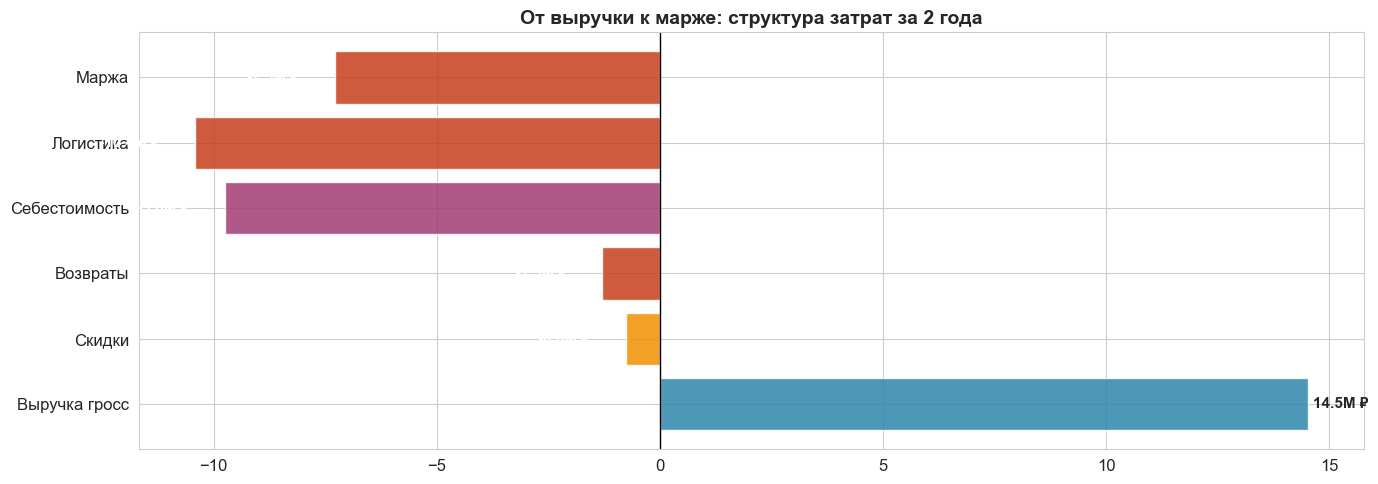


Детализация логистических затрат:
  delivery_to_pvz: 4,415,490 ₽ (39%)
  return_delivery: 406,752 ₽ (4%)
  storage_fbo: 6,240,411 ₽ (55%)
  storage_pvz: 371,910 ₽ (3%)


In [21]:
# Горизонтальный барчарт — путь от выручки к марже
fig, ax = plt.subplots(figsize=(14, 5))

categories_waterfall = [
    "Выручка гросс",
    "Скидки",
    "Возвраты",
    "Себестоимость",
    "Логистика",
    "Маржа"
]

values = [
    total_revenue_gross / 1_000_000,
    -total_discount / 1_000_000,
    -total_returns / 1_000_000,
    -total_cogs / 1_000_000,
    -total_logistics / 1_000_000,
    total_margin / 1_000_000,
]

colors_bar = [
    COLORS["profit"],
    COLORS["accent"],
    COLORS["warning"],
    COLORS["secondary"],
    COLORS["loss"],
    COLORS["profit"] if total_margin >= 0 else COLORS["loss"],
]

bars = ax.barh(categories_waterfall, values, color=colors_bar, alpha=0.85, edgecolor="white")

# Подписи значений
for bar, val in zip(bars, values):
    x_pos = bar.get_width()
    if val >= 0:
        ax.text(x_pos + 0.1, bar.get_y() + bar.get_height()/2, f"{val:,.1f}M ₽", 
                va="center", fontsize=11, fontweight="bold")
    else:
        ax.text(x_pos - 0.8, bar.get_y() + bar.get_height()/2, f"{val:,.1f}M ₽", 
                va="center", fontsize=11, fontweight="bold", ha="right", color="white")

ax.axvline(x=0, color="black", linewidth=1)
ax.set_title("От выручки к марже: структура затрат за 2 года", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Детализация логистики
print("\nДетализация логистических затрат:")
logistics_detail = logistics.groupby("cost_type", observed=False)["cost_amount"].sum()
for cost_type, amount in logistics_detail.items():
    pct = amount / logistics_detail.sum() * 100
    print(f"  {cost_type}: {amount:,.0f} ₽ ({pct:.0f}%)")

### 6.3. Ключевые проблемы и рекомендации

#### Проблема 1: Избыточные складские запасы (хранение FBO)

**Что обнаружил:**
- Хранение на складе маркетплейса обходится в 6.2 млн ₽ за 2 года (54.6% всех логистических затрат).
- FBO-товары имеют среднюю логистику 266 ₽/ед. против 106 ₽/ед. у FBS.
- Закупки превышают продажи почти в 2 раза — склад затоварен неликвидами.

**Рекомендации:**
- Провести ABC/XYZ-анализ и выявить неликвиды (товары с оборачиваемостью ниже порога).
- Для товаров с низкой оборачиваемостью — перейти на FBS (хранение на своём складе) или вывести из ассортимента.
- Оптимизировать график и объём закупок: перейти от закупок «с запасом» к закупкам на основе фактического спроса.
- **Оценка эффекта:** сокращение хранения FBO на 30% даст экономию ~ 1.9 млн ₽ за 2 года (~0.95 млн ₽/год).

#### Проблема 2: Хаотичные скидки без учёта маржинальности

**Что обнаружил:**
- 40% товаров продаются со скидкой, но скидки назначаются хаотично (2387 из 2422 товаров — ручные, несистемные).
- 1 223 товара были бы прибыльны без скидки, но со скидкой уходят в минус.
- Скидки выше 20% применяются к 5 541 продаже и дают маржинальность −244%.

**Рекомендации:**
- Внедрить правило «стоп-маржи»: запретить скидки, делающие товар убыточным.
- Ограничить максимальный размер скидки 10% без согласования руководителя.
- Перевести скидки на системную основу: плановые акции с фиксированным процентом, без ручного назначения.
- **Оценка эффекта:** сокращение потерь от скидок на 50% даст экономию ~ 0.38 млн ₽ за 2 года (~0.19 млн ₽/год).

#### Проблема 3: Возвраты и утилизация

**Что обнаружил:**
- Потери от возвратов: 1.29 млн ₽ за 2 года (8.9% от выручки нетто).
- 30% возвратов утилизируется, хотя часть — по причинам, не связанным с порчей товара («передумал»).
- «Не соответствует описанию» — вторая по частоте причина возвратов и утилизации.

**Рекомендации:**
- Улучшить контент: детальные фото, видео, реалистичные описания.
- Проверить политику утилизации: почему товары категории «передумал» списываются? Возможно, проблема в упаковке.
- Усилить входной контроль качества от поставщиков.
- **Оценка эффекта:** сокращение возвратов на 25% даст экономию ~ 0.32 млн ₽ за 2 года (~0.16 млн ₽/год).

#### Проблема 4: Убыточные категории — кандидаты на вывод

**Что обнаружил:**
- Напитки: маржинальность −180%, логистика = 201% от выручки.
- Бакалея: маржинальность −113%, логистика = 134% от выручки.
- Зоотовары (корма): маржинальность −79%, логистика = 100% от выручки.

**Рекомендации:**
- Для Напитков и Бакалеи — рассмотреть полный переход на FBS или отказ от категории, если логистика не позволяет выйти в плюс.
- Для Зоотоваров — выделить корма для животных в отдельный анализ: крупные упаковки (5–8 кг) убыточны из-за веса, мелкие (0.3–0.5 кг) могут быть рентабельны.
- **Оценка эффекта:** вывод из ассортимента топ-20% убыточных товаров в этих категориях сократит убытки на ~ 1.5 млн ₽ за 2 года (~0.75 млн ₽/год).

### 6.4. Оценка совокупного финансового эффекта

| Рекомендация | Эффект за 2 года | Эффект в год |
|---|---|---|
| Оптимизация хранения FBO (сокращение на 30%) | ~1 900 000 ₽ | ~950 000 ₽ |
| Наведение порядка со скидками | ~380 000 ₽ | ~190 000 ₽ |
| Сокращение возвратов на 25% | ~320 000 ₽ | ~160 000 ₽ |
| Вывод убыточных товаров (топ-20%) | ~1 500 000 ₽ | ~750 000 ₽ |
| **Итого** | **~4 100 000 ₽** | **~2 050 000 ₽** |

При текущем убытке 7.3 млн ₽ за 2 года эти меры позволят **сократить убытки более чем вдвое** и вывести бизнес на путь к безубыточности.

#### Что дальше?

В следующих ноутбуках я продолжу анализ:
- **Ноутбук 03:** RFM-анализ, когорты и LTV — кто наши лучшие клиенты и как повысить их пожизненную ценность?
- **Ноутбук 04:** ABC/XYZ-анализ, оборачиваемость и неликвиды — детальный план оптимизации складских запасов.